# Практическая работа 1 — Вариант 19 (HR‑аналитика)

В данной работе проводится анализ данных о сотрудниках компании с использованием фреймворка **Apache Spark (PySpark)** в соответствии с **вариантом 19 — HR‑аналитика (данные о сотрудниках: выработка, часы)**.

Целью работы является загрузка и обработка данных в HDFS, очистка выборки от уволенных сотрудников, расчёт показателей производительности и стажа по отделам, а также визуализация полученных результатов для последующей бизнес‑интерпретации.

## 0. Описание программного окружения

Работа выполнялась на виртуальной машине с преднастроенным образом `ds_mgpu_Hadoop3+spark_3_4`, включающим:

- Ubuntu 20.04+;
- Java 8/11;
- Hadoop 3.x (HDFS + YARN);
- Apache Spark 3.4.3 с поддержкой PySpark;
- Jupyter Notebook/JupyterLab/JupyterHub.

Данное окружение обеспечивает возможность развертывания кластера Hadoop, работы с HDFS и запуска PySpark‑приложений в интерактивном режиме.

## 1. Подготовка кластера Hadoop и загрузка данных в HDFS

Перед выполнением анализа был развернут кластер Hadoop и подготовлена структура каталогов в распределённой файловой системе.

Основные команды (выполнялись в терминале под пользователем `hadoop`):

```bash
sudo su - hadoop
start-dfs.sh
start-yarn.sh
jps

hdfs dfs -mkdir -p /user/hadoop/lab_01/input
hdfs dfs -chmod 775 /user/hadoop/lab_01

mkdir -p /home/hadoop/data
hdfs dfs -put /home/hadoop/data/Extended_Employee_Performance_and_Productivity_Data.csv \
  /user/hadoop/lab_01/input/

hdfs dfs -ls /user/hadoop/lab_01/input/
```

В результате датасет `Extended_Employee_Performance_and_Productivity_Data.csv` был успешно размещён в каталоге `/user/hadoop/lab_01/input/` в HDFS, что подтверждается выводом команды `hdfs dfs -ls`.

## 2. Импорт библиотек и инициализация SparkSession

На данном этапе были импортированы необходимые библиотеки PySpark и средств визуализации, после чего создан объект `SparkSession`, используемый для дальнейшей работы с данными.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, avg, sum as spark_sum
import matplotlib.pyplot as plt
import seaborn as sns

# Создаём SparkSession
spark = (
    SparkSession.builder
    .appName("Lab1_HR_Analytics_Variant19")
    .master("local[*]")
    .getOrCreate()
)

spark

26/03/03 17:02:02 WARN Utils: Your hostname, devopsvm resolves to a loopback address: 127.0.1.1; using 192.168.1.69 instead (on interface enp0s3)
26/03/03 17:02:02 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/03 17:02:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 3. Загрузка данных из HDFS (этап ETL)

На первом этапе ETL‑процесса данные о сотрудниках загружаются из HDFS по пути `/user/hadoop/lab_01/input/Extended_Employee_Performance_and_Productivity_Data.csv` в объект `DataFrame` PySpark. 

Выполняется автоматическое определение типов колонок (`inferSchema = true`), далее отображается схема датасета (`printSchema()`) и несколько первых строк выборки для визуальной проверки корректности загрузки.

In [ ]:
hdfs_path = "hdfs://localhost:9000/user/hadoop/lab_01/input/Extended_Employee_Performance_and_Productivity_Data.csv"

hr_df_raw = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(hdfs_path)
)

print("Всего строк в исходном датасете:", hr_df_raw.count())
hr_df_raw.printSchema()
hr_df_raw.show(10, truncate=False)

Всего строк в исходном датасете: 100000
root
 |-- Employee_ID: integer (nullable = true)
 |-- Department: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Job_Title: string (nullable = true)
 |-- Hire_Date: timestamp (nullable = true)
 |-- Years_At_Company: integer (nullable = true)
 |-- Education_Level: string (nullable = true)
 |-- Performance_Score: integer (nullable = true)
 |-- Monthly_Salary: double (nullable = true)
 |-- Work_Hours_Per_Week: integer (nullable = true)
 |-- Projects_Handled: integer (nullable = true)
 |-- Overtime_Hours: integer (nullable = true)
 |-- Sick_Days: integer (nullable = true)
 |-- Remote_Work_Frequency: integer (nullable = true)
 |-- Team_Size: integer (nullable = true)
 |-- Training_Hours: integer (nullable = true)
 |-- Promotions: integer (nullable = true)
 |-- Employee_Satisfaction_Score: double (nullable = true)
 |-- Resigned: boolean (nullable = true)

+-----------+----------------+------+---+

### 3.1. Проверка пропусков и базовый EDA (часть ETL)

В соответствии с требованиями методических указаний была выполнена проверка качества данных:
- подсчитано количество пропущенных значений (`NULL`) по каждой колонке;
- установлено, что во всех полях отсутствуют пропуски (все значения равны нулю);
- сделан вывод о корректности исходного датасета и возможности использовать его без дополнительной imputation‑обработки.

In [ ]:
from pyspark.sql.functions import count

# Подсчёт числа пропусков по каждому столбцу
null_counts = hr_df_raw.select([
    count(when(col(c).isNull(), c)).alias(c) for c in hr_df_raw.columns
])

null_counts.show(truncate=False)

+-----------+----------+------+---+---------+---------+----------------+---------------+-----------------+--------------+-------------------+----------------+--------------+---------+---------------------+---------+--------------+----------+---------------------------+--------+
|Employee_ID|Department|Gender|Age|Job_Title|Hire_Date|Years_At_Company|Education_Level|Performance_Score|Monthly_Salary|Work_Hours_Per_Week|Projects_Handled|Overtime_Hours|Sick_Days|Remote_Work_Frequency|Team_Size|Training_Hours|Promotions|Employee_Satisfaction_Score|Resigned|
+-----------+----------+------+---+---------+---------+----------------+---------------+-----------------+--------------+-------------------+----------------+--------------+---------+---------------------+---------+--------------+----------+---------------------------+--------+
|0          |0         |0     |0  |0        |0        |0               |0              |0                |0             |0                  |0               |0    

### 3.2. Очистка данных и фильтрация уволенных сотрудников (Вариант 19)

На следующем этапе в соответствии с вариантом 19 производится очистка выборки от уволенных сотрудников и расчёт дополнительного показателя производительности.

Используемые ключевые поля датасета `Extended_Employee_Performance_and_Productivity_Data.csv`:
- `Department` — отдел;
- `Monthly_Salary` — месячная заработная плата (принята как прокси‑оценка вклада сотрудника в выручку);
- `Work_Hours_Per_Week` — количество отработанных часов в неделю;
- `Years_At_Company` — стаж работы в компании (в годах);
- `Resigned` — булевый признак увольнения (`True` / `False`).

Из выборки исключаются записи с `Resigned = True`, после чего для каждого сотрудника вычисляется показатель `productivity_per_hour` — отношение месячной заработной платы к числу отработанных часов в неделю, используемый далее для агрегирования по отделам.

In [ ]:
# Настройка под Extended_Employee_Performance_and_Productivity_Data.csv

STATUS_COL = "Resigned"                 # True = уволился, False = работает
DEPT_COL = "Department"                 # отдел
REVENUE_COL = "Monthly_Salary"          # месячная зарплата — прокси «вклада/выручки» сотрудника
HOURS_COL = "Work_Hours_Per_Week"       # отработанные часы в неделю
TENURE_COL = "Years_At_Company"         # стаж в годах

# Фильтруем только действующих сотрудников (Resigned = False)
hr_df_active = hr_df_raw.where(col(STATUS_COL) == False)

print("Строк после фильтрации уволенных:", hr_df_active.count())

# Рассчитываем производительность сотрудника как зарплату на час
hr_df = hr_df_active.withColumn(
    "productivity_per_hour",
    when(col(HOURS_COL) > 0, col(REVENUE_COL) / col(HOURS_COL)).otherwise(None)
)

hr_df.select(*hr_df.columns[:10]).show(10, truncate=False)

Строк после фильтрации уволенных: 89990
+-----------+----------------+------+---+----------+--------------------------+----------------+---------------+-----------------+--------------+
|Employee_ID|Department      |Gender|Age|Job_Title |Hire_Date                 |Years_At_Company|Education_Level|Performance_Score|Monthly_Salary|
+-----------+----------------+------+---+----------+--------------------------+----------------+---------------+-----------------+--------------+
|1          |IT              |Male  |55 |Specialist|2022-01-19 08:03:05.556036|2               |High School    |5                |6750.0        |
|2          |Finance         |Male  |29 |Developer |2024-04-18 08:03:05.556036|0               |High School    |5                |7500.0        |
|3          |Finance         |Male  |55 |Specialist|2015-10-26 08:03:05.556036|8               |High School    |3                |5850.0        |
|4          |Customer Support|Female|48 |Analyst   |2016-10-22 08:03:05.556036|7    

## 4. Аналитика с помощью Spark SQL (Задание 2)

На втором этапе проводится аналитическая обработка очищенных данных с использованием механизма Spark SQL. 

Для этого датафрейм с рассчитанным показателем `productivity_per_hour` регистрируется как временное представление `hr_data`, после чего выполняется SQL‑запрос, рассчитывающий для каждого отдела:
- среднюю производительность сотрудника (`avg_productivity_per_hour`);
- средний стаж работы (`avg_tenure_years`);
- количество действующих сотрудников (`employees_count`).

Результаты упорядочиваются по убыванию средней производительности, что позволяет сформировать рейтинг отделов по эффективности.

In [5]:
# Регистрируем временное представление для Spark SQL
hr_df.createOrReplaceTempView("hr_data")

spark.sql("SELECT * FROM hr_data LIMIT 10").show(truncate=False)

+-----------+----------------+------+---+----------+--------------------------+----------------+---------------+-----------------+--------------+-------------------+----------------+--------------+---------+---------------------+---------+--------------+----------+---------------------------+--------+---------------------+
|Employee_ID|Department      |Gender|Age|Job_Title |Hire_Date                 |Years_At_Company|Education_Level|Performance_Score|Monthly_Salary|Work_Hours_Per_Week|Projects_Handled|Overtime_Hours|Sick_Days|Remote_Work_Frequency|Team_Size|Training_Hours|Promotions|Employee_Satisfaction_Score|Resigned|productivity_per_hour|
+-----------+----------------+------+---+----------+--------------------------+----------------+---------------+-----------------+--------------+-------------------+----------------+--------------+---------+---------------------+---------+--------------+----------+---------------------------+--------+---------------------+
|1          |IT          

In [6]:
# SQL-запрос по варианту 19: производительность и средний стаж по отделам

query = f"""
SELECT
  {DEPT_COL} AS department,
  AVG(productivity_per_hour) AS avg_productivity_per_hour,
  AVG(CAST({TENURE_COL} AS DOUBLE)) AS avg_tenure_years,
  COUNT(*) AS employees_count
FROM hr_data
GROUP BY {DEPT_COL}
ORDER BY avg_productivity_per_hour DESC
"""

dept_metrics_df = spark.sql(query)
dept_metrics_df.show(truncate=False)

+----------------+-------------------------+------------------+---------------+
|department      |avg_productivity_per_hour|avg_tenure_years  |employees_count|
+----------------+-------------------------+------------------+---------------+
|Customer Support|148.90480132010663       |4.470053902974645 |10018          |
|Operations      |148.89939663581873       |4.47117296222664  |10060          |
|IT              |148.79972622802885       |4.43866097149101  |10067          |
|Engineering     |148.65474872005507       |4.490251540559653 |9899           |
|HR              |148.5389296550078        |4.479003558718861 |9835           |
|Sales           |148.41296314729917       |4.466959472948693 |10018          |
|Finance         |148.29956283574052       |4.47814371257485  |10020          |
|Marketing       |148.1186619820249        |4.5020315132296105|10091          |
|Legal           |147.99022696961234       |4.48186736125025  |9982           |
+----------------+----------------------

## 5. Визуализация результатов (Задание 3)

Заключительным шагом работы является визуализация полученных агрегированных метрик и их бизнес‑интерпретация.

Для варианта 19 (HR‑аналитика) построена комбинированная диаграмма эффективности отделов:
- по оси X откладываются названия отделов;
- по оси Y (левая шкала) отображается средняя производительность `avg_productivity_per_hour` в виде столбчатой диаграммы;
- по оси Y (правая шкала) отображается средний стаж `avg_tenure_years` в виде линейного графика.

Такая визуализация позволяет одновременно сравнить отделы по уровню эффективности и по накопленному опыту сотрудников.

In [7]:
# Переносим агрегированные метрики в Pandas для визуализации
dept_metrics_pd = dept_metrics_df.toPandas()

dept_metrics_pd

,department,avg_productivity_per_hour,avg_tenure_years,employees_count
0,Customer Support,148.904801,4.470054,10018
1,Operations,148.899397,4.471173,10060
2,IT,148.799726,4.438661,10067
3,Engineering,148.654749,4.490252,9899
4,HR,148.538930,4.479004,9835
5,Sales,148.412963,4.466959,10018
6,Finance,148.299563,4.478144,10020
7,Marketing,148.118662,4.502032,10091
8,Legal,147.990227,4.481867,9982


/tmp/ipykernel_5567/390376823.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


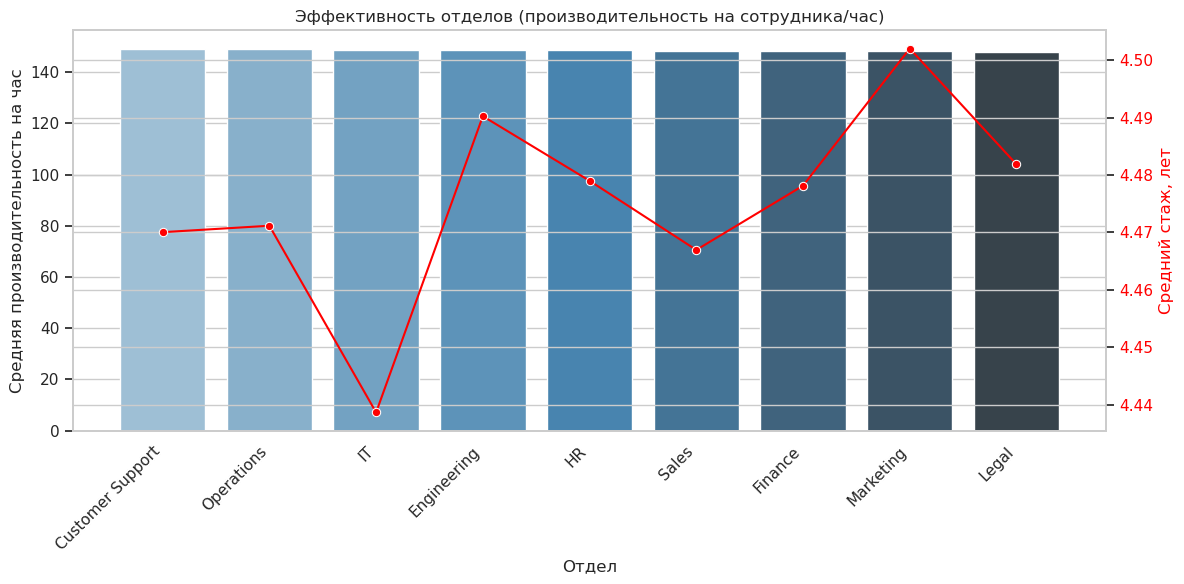

In [ ]:
# отделы по производительности и среднему стажу
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Сортируем отделы по убыванию производительности
dept_metrics_pd_sorted = dept_metrics_pd.sort_values("avg_productivity_per_hour", ascending=False)

ax = sns.barplot(
    data=dept_metrics_pd_sorted,
    x="department",
    y="avg_productivity_per_hour",
    palette="Blues_d"
)
ax.set_title("Эффективность отделов (производительность на сотрудника/час)")
ax.set_xlabel("Отдел")
ax.set_ylabel("Средняя производительность на час")
plt.xticks(rotation=45, ha="right")

# Вторая ось для среднего стажа
ax2 = ax.twinx()
sns.lineplot(
    data=dept_metrics_pd_sorted,
    x="department",
    y="avg_tenure_years",
    color="red",
    marker="o",
    ax=ax2
)
ax2.set_ylabel("Средний стаж, лет", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.tight_layout()
plt.show()